# 蒙特卡洛模拟 - 定增收益预测

## 分析目标
使用蒙特卡洛方法模拟定增项目的收益分布，包括：
- 股价路径模拟（几何布朗运动）
- 定增收益分布
- 盈利/亏损概率分析
- 收益率区间预测
- **多窗口期分析（60日/120日/250日）**

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from utils.analysis_tools import PrivatePlacementRiskAnalyzer

# 直接配置中文字体（适用于vnpy等虚拟环境）
from utils.direct_font_config import setup
setup()

# 获取字体属性（用于绘图时设置字体）
from utils.font_manager import get_font_prop
font_prop = get_font_prop()

%matplotlib inline
sns.set_style('whitegrid')

print('✅ 蒙特卡洛模拟模块加载成功')

✅ 使用字体: Heiti TC
   路径: /System/Library/Fonts/STHeiti Medium.ttc
✅ 使用系统字体: /System/Library/Fonts/STHeiti Medium.ttc
✅ 蒙特卡洛模拟模块加载成功


## 1. 参数设置与模拟器初始化

In [2]:
# ============================================================
# 加载定增分析配置（使用真实数据）
# ============================================================
from utils.config_loader import load_placement_config, print_config_summary
from utils.analysis_tools import PrivatePlacementRiskAnalyzer

# 加载配置（自动尝试使用真实市场数据）
print("正在加载配置...")
project_params, risk_params, market_data = load_placement_config('300735.SZ')

# 打印配置摘要
print_config_summary(project_params, risk_params, market_data)

# 创建分析器
analyzer = PrivatePlacementRiskAnalyzer(**project_params)

# ============================================================
# 蒙特卡洛模拟参数
# ============================================================
MC_PARAMS = {
    'n_simulations': 10000,
    'volatility': risk_params['volatility'],  # 使用真实波动率
    'drift': risk_params['drift'],             # 使用真实收益率
    'time_steps': 252,
    'seed': 42
}

print(f"\n📊 蒙特卡洛模拟参数:")
print(f"   模拟次数: {MC_PARAMS['n_simulations']:,}")
print(f"   波动率: {MC_PARAMS['volatility']*100:.2f}% (来源: {risk_params.get('data_source', 'unknown')})")
print(f"   漂移率: {MC_PARAMS['drift']*100:.2f}% (来源: {risk_params.get('data_source', 'unknown')})")

正在加载配置...
✅ 已加载定增参数: ../300735_SZ_placement_params.json
✅ 已加载市场数据: ../300735_SZ_market_data.json
   股票: 光弘科技 (300735.SZ)
   分析日期: 20260306
   当前价格: 23.88 元
✅ 使用市场数据中的最新价格: 23.88 元
✅ 使用真实市场数据:
   波动率: 30.63% (60日)
   收益率: -18.75% (60日年化)

📊 定增分析配置

📋 项目参数:
   发行价格: 20.25 元/股
   当前价格: 23.88 元/股
   锁定期: 6 个月
   发行数量: 5,000,000 股
   融资金额: 1.01 亿元
   当前收益率: +17.95% （浮盈）

📌 发行类型判断:
   MA30: 25.31 元
   发行价: 20.25 元
   ✅ 折价发行（有安全边际）
   安全边际: 20.01%

⚠️ 风险参数:
   波动率: 30.63%
   收益率(漂移率): -18.75%
   数据来源: market_data

📈 波动率详情:
   30日: 33.96%
   60日: 30.63%
   120日: 37.13%
   180日: 36.60%

📊 蒙特卡洛模拟参数:
   模拟次数: 10,000
   波动率: 30.63% (来源: market_data)
   漂移率: -18.75% (来源: market_data)


## 2. 运行蒙特卡洛模拟

In [3]:
# 运行模拟
print("开始蒙特卡洛模拟，请稍候...")

sim_results = analyzer.monte_carlo_simulation(
    n_simulations=MC_PARAMS['n_simulations'],
    time_steps=MC_PARAMS['time_steps'],
    volatility=MC_PARAMS['volatility'],
    drift=MC_PARAMS['drift'],
    seed=MC_PARAMS['seed']
)

print(f"✅ 模拟完成！生成 {MC_PARAMS['n_simulations']:,} 条路径")
print(f"\n模拟结果形状: {sim_results.shape}")

开始蒙特卡洛模拟，请稍候...
✅ 模拟完成！生成 10,000 条路径

模拟结果形状: (10000, 181)


## 3. 模拟路径可视化

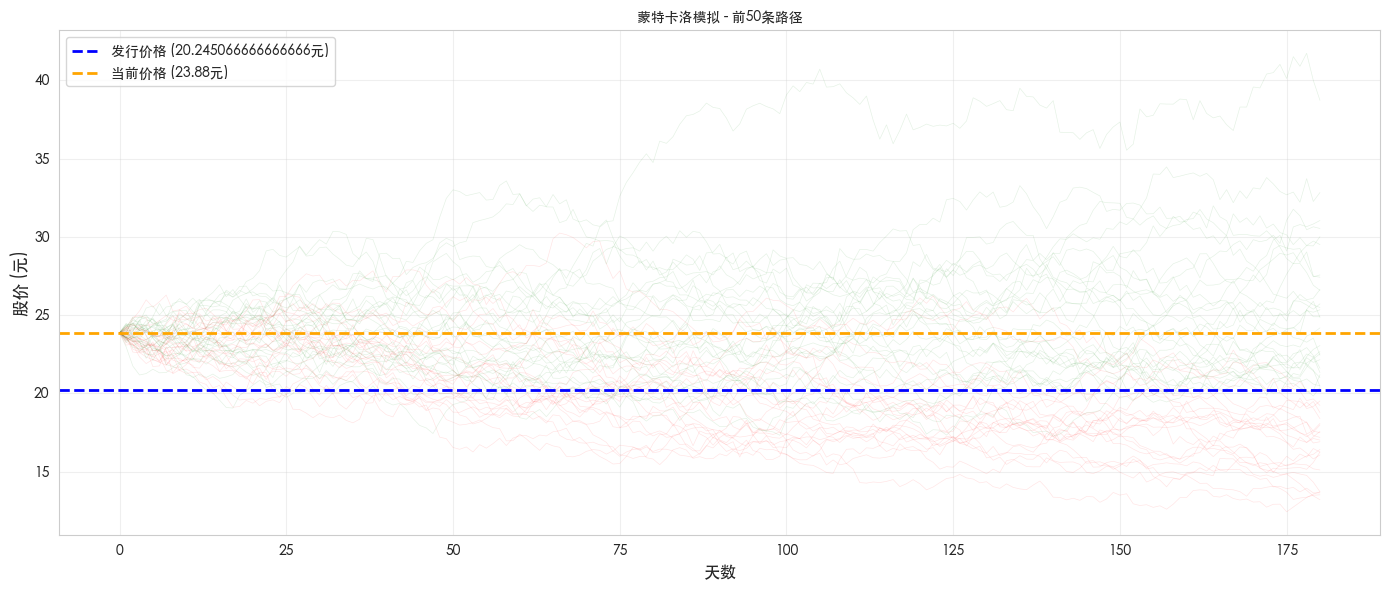

In [4]:
# 生成模拟路径可视化所需的变量
# 随机选择一些路径进行可视化
import random
n_paths_to_plot = 50  # 显示前50条路径
random_paths = random.sample(range(sim_results.shape[0]), n_paths_to_plot)
days_to_plot = project_params['lockup_period'] * 30  # 锁定期的天数

fig, ax = plt.subplots(figsize=(14, 6))

# 绘制模拟路径
for i in range(n_paths_to_plot):
    path = sim_results.iloc[random_paths[i], :days_to_plot+1].values
    alpha = 0.1
    color = 'green' if path[-1] >= project_params['issue_price'] else 'red'
    ax.plot(range(days_to_plot+1), path, color=color, alpha=alpha, linewidth=0.5)

# 绘制关键水平线
ax.axhline(y=project_params['issue_price'], color='blue', linestyle='--', 
        linewidth=2, label=f"发行价格 ({project_params['issue_price']}元)")
ax.axhline(y=project_params['current_price'], color='orange', linestyle='--', 
        linewidth=2, label=f"当前价格 ({project_params['current_price']}元)")

ax.set_xlabel('天数', fontsize=12, fontproperties=font_prop)
ax.set_ylabel('股价 (元)', fontsize=12, fontproperties=font_prop)
ax.set_title(f'蒙特卡洛模拟 - 前{n_paths_to_plot}条路径', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax.legend(loc='upper left', prop=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 收益分布分析

In [5]:
# 计算锁定期天数
lockup_days = project_params['lockup_period'] * 30  # 将月转换为天

# 提取锁定期末的价格
final_prices = sim_results.iloc[:, lockup_days].values

# 计算收益率
returns = (final_prices - project_params['issue_price']) / project_params['issue_price']

# 计算年化收益率
annualized_returns = (1 + returns) ** (12 / project_params['lockup_period']) - 1

# 统计摘要
print('\n=== 收益分布统计 ===')
print(f"平均收益率: {annualized_returns.mean()*100:.2f}%")
print(f"中位数收益率: {np.median(annualized_returns)*100:.2f}%")
print(f"标准差: {annualized_returns.std()*100:.2f}%")
print(f"\n盈利概率: {(returns > 0).sum() / len(returns) * 100:.2f}%")
print(f"破发概率: {(returns <= 0).sum() / len(returns) * 100:.2f}%")
print(f"\n最佳情况收益率: {annualized_returns.max()*100:.2f}%")
print(f"最差情况收益率: {annualized_returns.min()*100:.2f}%")


=== 收益分布统计 ===
平均收益率: 12.84%
中位数收益率: -1.18%
标准差: 62.56%

盈利概率: 49.18%
破发概率: 50.82%

最佳情况收益率: 566.56%
最差情况收益率: -89.93%


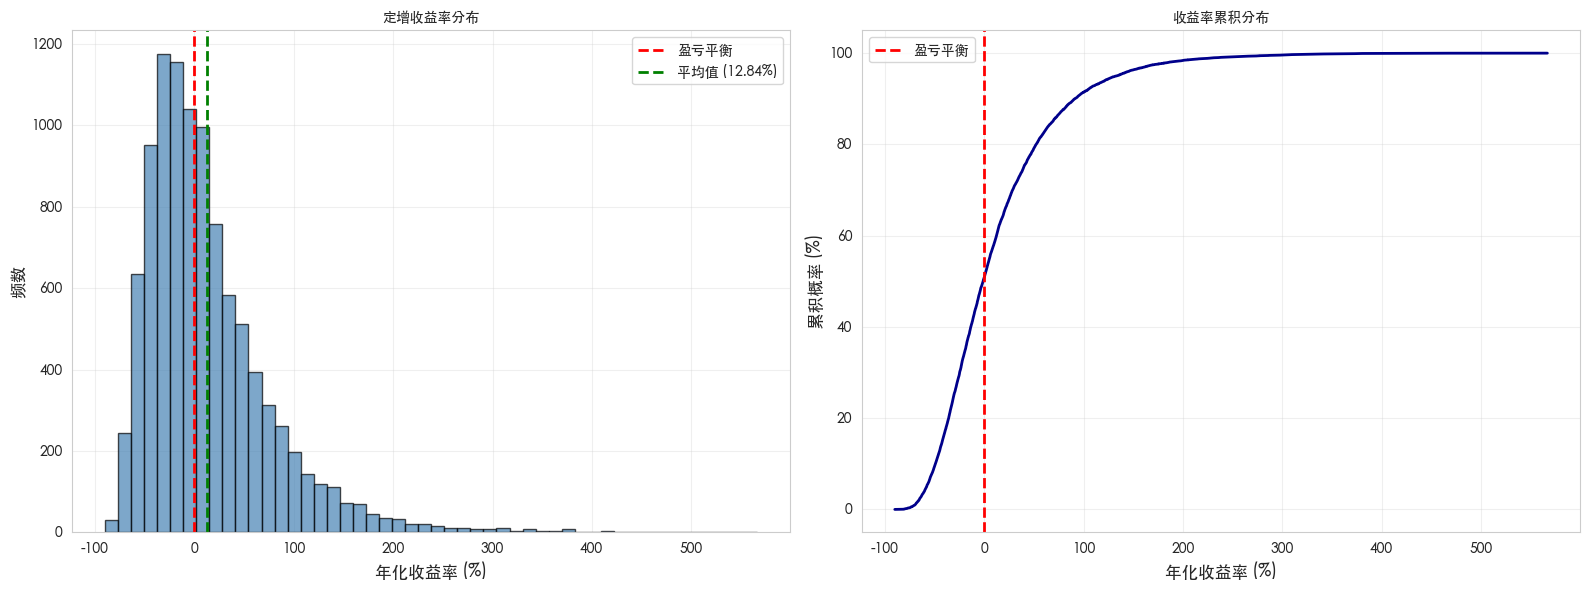

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 简单收益率分布
ax1.hist(annualized_returns * 100, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='盈亏平衡')
ax1.axvline(x=np.mean(annualized_returns)*100, color='green', linestyle='--', 
         linewidth=2, label=f"平均值 ({np.mean(annualized_returns)*100:.2f}%)")
ax1.set_xlabel('年化收益率 (%)', fontsize=12, fontproperties=font_prop)
ax1.set_ylabel('频数', fontsize=12, fontproperties=font_prop)
ax1.set_title('定增收益率分布', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax1.legend(prop=font_prop)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)
ax1.grid(True, alpha=0.3)

# 累积分布函数
sorted_returns = np.sort(annualized_returns)
cumulative = np.arange(1, len(sorted_returns) + 1) / len(sorted_returns)
ax2.plot(sorted_returns * 100, cumulative * 100, linewidth=2, color='darkblue')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='盈亏平衡')
ax2.set_xlabel('年化收益率 (%)', fontsize=12, fontproperties=font_prop)
ax2.set_ylabel('累积概率 (%)', fontsize=12, fontproperties=font_prop)
ax2.set_title('收益率累积分布', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax2.legend(prop=font_prop)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 收益率区间预测

In [7]:
# 计算不同置信水平下的收益率区间
confidence_levels = [0.50, 0.68, 0.80, 0.90, 0.95]

print('\n=== 收益率区间预测 ===')
print(f"{'置信水平':<12} {'收益率区间':<30} {'最差情况':<15} {'最好情况':<15}")
print('-'*72)

for cl in confidence_levels:
    lower = np.percentile(annualized_returns, (1-cl)/2 * 100)
    upper = np.percentile(annualized_returns, (1+cl)/2 * 100)
    worst = np.percentile(annualized_returns, (1-cl) * 100)
    best = np.percentile(annualized_returns, cl * 100)
    
    print(f"{int(cl*100):>3}%:        [{lower*100:>7.2f}%, {upper*100:>7.2f}%]      {worst*100:>7.2f}%      {best*100:>7.2f}%")


=== 收益率区间预测 ===
置信水平         收益率区间                          最差情况            最好情况           
------------------------------------------------------------------------
 50%:        [ -30.55%,   39.76%]        -1.18%        -1.18%
 68%:        [ -40.81%,   64.62%]       -22.55%        24.94%
 80%:        [ -49.12%,   91.13%]       -35.76%        52.23%
 90%:        [ -57.90%,  132.99%]       -49.12%        91.13%
 95%:        [ -64.40%,  171.39%]       -57.90%       132.99%


## 6. 不同情景分析

In [8]:
# 情景分析：不同波动率下的收益表现
volatility_scenarios = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
scenario_results = []

print("运行不同波动率情景分析...")
for vol in volatility_scenarios:
    # 使用相同参数但不同波动率运行模拟
    sim_scenario = analyzer.monte_carlo_simulation(
        n_simulations=2000,  # 减少模拟次数以加快速度
        time_steps=MC_PARAMS['time_steps'],
        volatility=vol,
        drift=MC_PARAMS['drift'],
        seed=None  # 不使用固定种子
    )
    
    # 提取结果
    final_prices_scenario = sim_scenario.iloc[:, lockup_days].values
    returns_scenario = (final_prices_scenario - project_params['issue_price']) / project_params['issue_price']
    annualized_returns_scenario = (1 + returns_scenario) ** (12 / project_params['lockup_period']) - 1
    
    scenario_results.append({
        'volatility': vol,
        'mean_return': annualized_returns_scenario.mean(),
        'std_return': annualized_returns_scenario.std(),
        'profit_prob': (returns_scenario > 0).sum() / len(returns_scenario),
        'percentile_5': np.percentile(annualized_returns_scenario, 5),
        'percentile_25': np.percentile(annualized_returns_scenario, 25),
        'percentile_50': np.percentile(annualized_returns_scenario, 50),
        'percentile_75': np.percentile(annualized_returns_scenario, 75),
        'percentile_95': np.percentile(annualized_returns_scenario, 95)
    })

df_scenarios = pd.DataFrame(scenario_results)
print("✅ 情景分析完成")
print(df_scenarios)

运行不同波动率情景分析...
✅ 情景分析完成
   volatility  mean_return  std_return  profit_prob  percentile_5  \
0        0.20     0.093086    0.364158       0.5385     -0.391551   
1        0.25     0.128237    0.506608       0.5235     -0.464584   
2        0.30     0.122698    0.606709       0.4875     -0.573773   
3        0.35     0.144155    0.712996       0.4825     -0.622827   
4        0.40     0.197026    0.890789       0.4710     -0.664000   
5        0.45     0.268200    1.170065       0.4700     -0.734821   
6        0.50     0.270556    1.385607       0.4415     -0.785622   

   percentile_25  percentile_50  percentile_75  percentile_95  
0      -0.165667       0.034568       0.293427       0.785029  
1      -0.222772       0.023298       0.374478       1.079686  
2      -0.292179      -0.011706       0.402267       1.242249  
3      -0.328520      -0.027927       0.421864       1.548469  
4      -0.383760      -0.051487       0.494285       1.955686  
5      -0.442392      -0.056658       0

## 6. 不同情景分析

In [9]:
# 计算风险调整后收益指标
# 夏普比率 = (预期收益率 - 无风险利率) / 收益率标准差
sharpe = (annualized_returns.mean() - project_params['risk_free_rate']) / annualized_returns.std()

# 收益风险比 = 预期收益率 / 收益率标准差
reward_to_risk = annualized_returns.mean() / annualized_returns.std()

# 索提诺比率 = (预期收益率 - 无风险利率) / 下行风险标准差
# 计算下行风险（只考虑负收益）
downside_returns = annualized_returns[annualized_returns < 0]
if len(downside_returns) > 0:
    downside_std = downside_returns.std()
    sortino = (annualized_returns.mean() - project_params['risk_free_rate']) / downside_std
else:
    sortino = np.nan  # 如果没有负收益，索提诺比率无意义

print("风险调整后收益指标:")
print(f"夏普比率: {sharpe:.3f}")
print(f"收益风险比: {reward_to_risk:.3f}")
print(f"索提诺比率: {sortino:.3f}")

风险调整后收益指标:
夏普比率: 0.157
收益风险比: 0.205
索提诺比率: 0.522


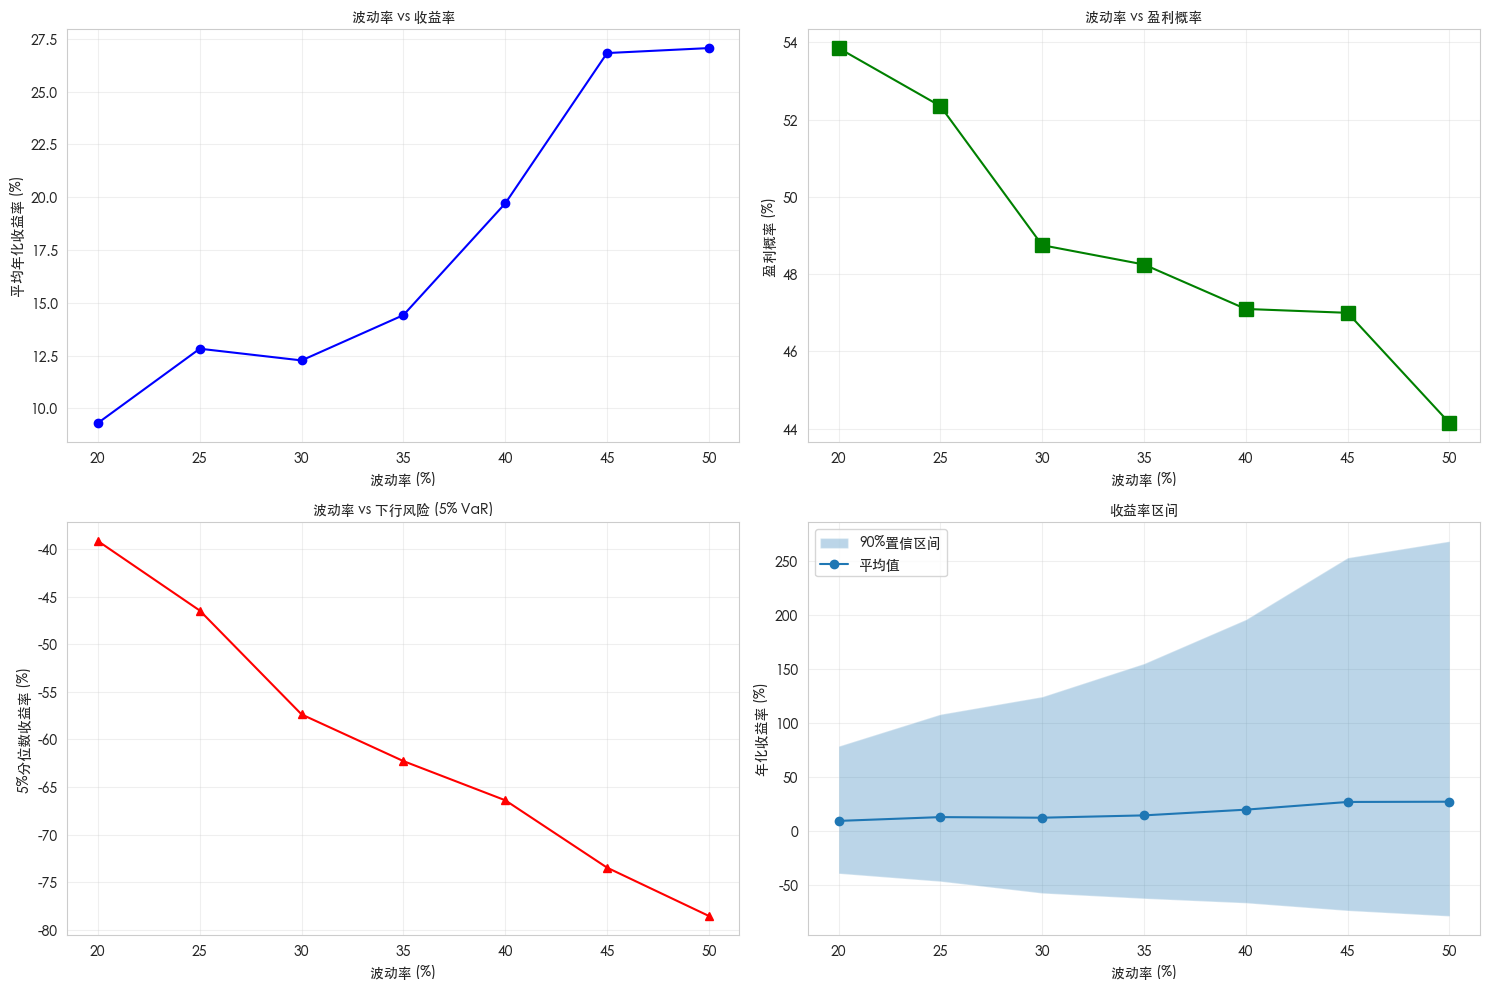

In [10]:
# 可视化
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. 平均收益率 vs 波动率
ax1.plot(df_scenarios['volatility']*100, df_scenarios['mean_return']*100, 'o-', color='blue')
ax1.set_xlabel('波动率 (%)', fontproperties=font_prop)
ax1.set_ylabel('平均年化收益率 (%)', fontproperties=font_prop)
ax1.set_title('波动率 vs 收益率', fontproperties=font_prop)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)
ax1.grid(True, alpha=0.3)

# 2. 盈利概率 vs 波动率
ax2.plot(df_scenarios['volatility']*100, df_scenarios['profit_prob']*100, 's-', color='green', markersize=10)
ax2.set_xlabel('波动率 (%)', fontproperties=font_prop)
ax2.set_ylabel('盈利概率 (%)', fontproperties=font_prop)
ax2.set_title('波动率 vs 盈利概率', fontproperties=font_prop)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)
ax2.grid(True, alpha=0.3)

# 3. 5%分位数 vs 波动率
ax3.plot(df_scenarios['volatility']*100, df_scenarios['percentile_5']*100, '^-', color='red')
ax3.set_xlabel('波动率 (%)', fontproperties=font_prop)
ax3.set_ylabel('5%分位数收益率 (%)', fontproperties=font_prop)
ax3.set_title('波动率 vs 下行风险 (5% VaR)', fontproperties=font_prop)
for label in ax3.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax3.get_yticklabels():
    label.set_fontproperties(font_prop)
ax3.grid(True, alpha=0.3)

# 4. 收益区间 (5%-95%)
ax4.fill_between(df_scenarios['volatility']*100, 
                 df_scenarios['percentile_5']*100, 
                 df_scenarios['percentile_95']*100, alpha=0.3, label='90%置信区间')
ax4.plot(df_scenarios['volatility']*100, df_scenarios['mean_return']*100, 'o-', label='平均值')
ax4.set_xlabel('波动率 (%)', fontproperties=font_prop)
ax4.set_ylabel('年化收益率 (%)', fontproperties=font_prop)
ax4.set_title('收益率区间', fontproperties=font_prop)
ax4.legend(prop=font_prop)
for label in ax4.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax4.get_yticklabels():
    label.set_fontproperties(font_prop)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 风险调整后收益

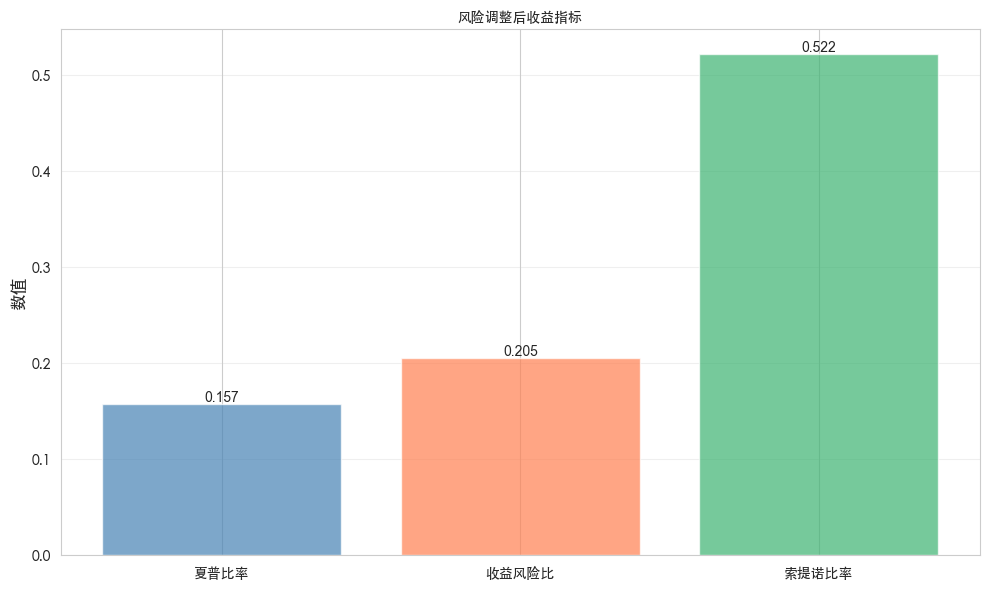

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['夏普比率', '收益风险比', '索提诺比率']
values = [sharpe, reward_to_risk, sortino]
colors = ['steelblue', 'coral', 'mediumseagreen']

bars = ax.bar(metrics, values, color=colors, alpha=0.7)
ax.set_ylabel('数值', fontsize=12, fontproperties=font_prop)
ax.set_title('风险调整后收益指标', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, axis='y', alpha=0.3)

# 添加数值标签
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 8. 蒙特卡洛模拟结论

In [12]:
print('\n' + '='*60)
print('蒙特卡洛模拟结论')
print('='*60)

print(f"\n📊 模拟配置:")
print(f"   模拟次数: {MC_PARAMS['n_simulations']:,}")
print(f"   假设波动率: {MC_PARAMS['volatility']*100:.0f}%")
print(f"   假设漂移率: {MC_PARAMS['drift']*100:.0f}%")

print(f"\n📈 收益预测:")
print(f"   预期年化收益率: {annualized_returns.mean()*100:.2f}%")
print(f"   中位数收益率: {np.median(annualized_returns)*100:.2f}%")
print(f"   90%置信区间: [{np.percentile(annualized_returns, 5)*100:.2f}%, {np.percentile(annualized_returns, 95)*100:.2f}%]")

print(f"\n⚠️ 风险评估:")
print(f"   盈利概率: {(returns > 0).sum() / len(returns) * 100:.1f}%")
print(f"   破发概率: {(returns <= 0).sum() / len(returns) * 100:.1f}%")
print(f"   夏普比率: {sharpe:.3f}")

# 风险等级判断
profit_prob = (returns > 0).sum() / len(returns)
if profit_prob >= 0.7:
    risk_level = "低风险"
    color = "🟢"
elif profit_prob >= 0.5:
    risk_level = "中等风险"
    color = "🟡"
else:
    risk_level = "高风险"
    color = "🔴"

print(f"\n{color} 综合风险评级: {risk_level}")


蒙特卡洛模拟结论

📊 模拟配置:
   模拟次数: 10,000
   假设波动率: 31%
   假设漂移率: -19%

📈 收益预测:
   预期年化收益率: 12.84%
   中位数收益率: -1.18%
   90%置信区间: [-57.90%, 132.99%]

⚠️ 风险评估:
   盈利概率: 49.2%
   破发概率: 50.8%
   夏普比率: 0.157

🔴 综合风险评级: 高风险


## 10. 多窗口期分析结论

不同窗口期的蒙特卡洛模拟揭示了以下关键发现：

### 时间窗口期的影响

1. **短期（60日）**：
   - 基于近2个月的短期市场表现
   - 波动率和收益率更能反映当前市场情绪
   - 适合短期交易决策参考

2. **中期（120日/半年线）**：
   - 基于约半年的市场数据
   - 平衡了短期波动和长期趋势
   - 是中期投资的重要参考

3. **长期（250日/年线）**：
   - 基于近1年的长期市场表现
   - 反映长期基本面和趋势
   - 适合长期投资决策

### 窗口期选择建议

- **保守型投资者**：建议参考120日或250日窗口，更加稳健
- **激进型投资者**：可参考60日窗口，捕捉短期机会
- **平衡型投资者**：综合参考多个窗口期，做综合判断

### 风险提示

不同窗口期的模拟结果可能存在显著差异，建议：
- 不要过度依赖单一窗口期的结果
- 结合多个窗口期做综合判断
- 考虑市场环境变化对窗口期有效性的影响

In [ ]:
# 多窗口期可视化对比
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 准备数据
window_names = list(multi_window_results.keys())
vols = [multi_window_results[w]['volatility']*100 for w in window_names]
drifts = [multi_window_results[w]['drift']*100 for w in window_names]
mean_returns = [multi_window_results[w]['mean_return']*100 for w in window_names]
profit_probs = [multi_window_results[w]['profit_prob']*100 for w in window_names]

# 1. 波动率对比
ax1 = axes[0, 0]
bars1 = ax1.bar(window_names, vols, color='steelblue', alpha=0.7)
ax1.set_ylabel('波动率 (%)', fontproperties=font_prop, fontsize=12)
ax1.set_title('不同窗口期的波动率对比', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for bar, vol in zip(bars1, vols):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{vol:.1f}%', ha='center', va='bottom', fontproperties=font_prop, fontsize=11)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)

# 2. 收益率对比
ax2 = axes[0, 1]
bars2 = ax2.bar(window_names, drifts, color='coral', alpha=0.7)
ax2.set_ylabel('收益率 (%)', fontproperties=font_prop, fontsize=12)
ax2.set_title('不同窗口期的收益率对比', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
for bar, drift in zip(bars2, drifts):
    y_pos = drift + 2 if drift > 0 else drift - 3
    ha = 'center' if drift > 0 else 'center'
    ax2.text(bar.get_x() + bar.get_width()/2, y_pos,
            f'{drift:.1f}%', ha='center', va='bottom' if drift > 0 else 'top',
            fontproperties=font_prop, fontsize=11)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)

# 3. 预期年化收益率对比
ax3 = axes[1, 0]
bars3 = ax3.bar(window_names, mean_returns, color='green' if [r > 0 for r in mean_returns].count(True) > 1 else 'red', alpha=0.7)
ax3.set_ylabel('预期年化收益率 (%)', fontproperties=font_prop, fontsize=12)
ax3.set_title('不同窗口期的预期收益率对比', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1)
for bar, ret in zip(bars3, mean_returns):
    y_pos = ret + 3 if ret > 0 else ret - 4
    ha = 'center'
    ax3.text(bar.get_x() + bar.get_width()/2, y_pos,
            f'{ret:.1f}%', ha='center', va='bottom' if ret > 0 else 'top',
            fontproperties=font_prop, fontsize=11)
for label in ax3.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax3.get_yticklabels():
    label.set_fontproperties(font_prop)

# 4. 盈利概率对比
ax4 = axes[1, 1]
bars4 = ax4.bar(window_names, profit_probs, color='purple', alpha=0.7)
ax4.set_ylabel('盈利概率 (%)', fontproperties=font_prop, fontsize=12)
ax4.set_title('不同窗口期的盈利概率对比', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax4.set_ylim(0, 100)
ax4.grid(True, alpha=0.3, axis='y')
for bar, prob in zip(bars4, profit_probs):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{prob:.1f}%', ha='center', va='bottom', fontproperties=font_prop, fontsize=11)
for label in ax4.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax4.get_yticklabels():
    label.set_fontproperties(font_prop)

plt.suptitle('蒙特卡洛模拟 - 多窗口期对比分析', fontproperties=font_prop, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 多窗口期结果对比表
comparison_data = []
for window_name, results in multi_window_results.items():
    comparison_data.append({
        '窗口期': window_name,
        '波动率': f"{results['volatility']*100:.2f}%",
        '收益率': f"{results['drift']*100:.2f}%",
        '预期年化收益': f"{results['mean_return']*100:.2f}%",
        '中位数收益': f"{results['median_return']*100:.2f}%",
        '盈利概率': f"{results['profit_prob']*100:.1f}%",
        '5% VaR': f"{results['percentile_5']*100:.2f}%",
        '95% VaR': f"{results['percentile_95']*100:.2f}%"
    })

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("📊 多窗口期蒙特卡洛模拟对比")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)

In [ ]:
# 多窗口期参数配置
windows_analysis = {
    '60日': {'days': 60, 'volatility_key': 'volatility_60d', 'return_key': 'annual_return_60d'},
    '120日': {'days': 120, 'volatility_key': 'volatility_120d', 'return_key': 'annual_return_120d'},
    '250日': {'days': 250, 'volatility_key': 'volatility_250d', 'return_key': 'annual_return_250d'}
}

print("="*70)
print("📊 多窗口期蒙特卡洛模拟分析")
print("="*70)
print(f"\n分析窗口:")
for name, config in windows_analysis.items():
    vol = market_data.get(config['volatility_key'], 0)
    ret = market_data.get(config['return_key'], 0)
    print(f"  {name:>6}: 波动率={vol*100:>6.2f}%, 收益率={ret*100:>7.2f}%")

# 为每个窗口期运行模拟
multi_window_results = {}

print(f"\n开始多窗口期模拟...")
for window_name, config in windows_analysis.items():
    print(f"\n正在模拟 {window_name}...")
    
    # 获取该窗口期的波动率和收益率
    window_vol = market_data.get(config['volatility_key'], MC_PARAMS['volatility'])
    window_return = market_data.get(config['return_key'], MC_PARAMS['drift'])
    
    # 运行模拟
    sim_window = analyzer.monte_carlo_simulation(
        n_simulations=5000,  # 使用5000次模拟以加快速度
        time_steps=config['days'],
        volatility=window_vol,
        drift=window_return,
        seed=42
    )
    
    # 提取最终价格和收益率
    final_prices_window = sim_window.iloc[:, -1].values
    returns_window = (final_prices_window - project_params['issue_price']) / project_params['issue_price']
    annualized_returns_window = (1 + returns_window) ** (12 / project_params['lockup_period']) - 1
    
    # 统计分析
    multi_window_results[window_name] = {
        'volatility': window_vol,
        'drift': window_return,
        'final_prices': final_prices_window,
        'returns': returns_window,
        'annualized_returns': annualized_returns_window,
        'mean_return': annualized_returns_window.mean(),
        'median_return': np.median(annualized_returns_window),
        'std_return': annualized_returns_window.std(),
        'profit_prob': (returns_window > 0).mean(),
        'percentile_5': np.percentile(annualized_returns_window, 5),
        'percentile_25': np.percentile(annualized_returns_window, 25),
        'percentile_75': np.percentile(annualized_returns_window, 75),
        'percentile_95': np.percentile(annualized_returns_window, 95),
    }
    
    print(f"  预期收益率: {multi_window_results[window_name]['mean_return']*100:>7.2f}%")
    print(f"  盈利概率: {multi_window_results[window_name]['profit_prob']*100:>6.2f}%")

print(f"\n✅ 多窗口期模拟完成")

## 9. 多窗口期分析（60日/120日/250日）

本节分析不同时间窗口下的蒙特卡洛模拟结果，对比不同窗口期的波动率和收益率表现。